# Twitter / X Sentiment Analysis

**Goal:** Classify tweets into sentiment classes (Positive / Negative / Neutral) using classical ML (TF-IDF + Logistic Regression / SVM / Naive Bayes) and a small LSTM, with extensive EDA and comparative analysis.

**Dataset:** Tweet Sentiment Extraction (Kaggle) — `kazanova/tweet-sentiment-extraction-data` style (we use a Hugging Face mirror for reliability).

**Pipeline:**
1. Setup & Imports
2. Load Dataset (Hugging Face fallback → Kaggle)
3. Comprehensive EDA — class balance, tweet length, word frequency, n-grams
4. Multivariate Analysis — length × sentiment, polarity-vs-length heatmap
5. Word Clouds per Class
6. Text Cleaning
7. TF-IDF + Logistic Regression (baseline)
8. TF-IDF + Multinomial Naive Bayes
9. TF-IDF + Linear SVM
10. Small LSTM (Keras)
11. Comparative Evaluation
12. Conclusion

## 1. Setup & Imports

In [ ]:
!pip install -q datasets wordcloud scikit-learn nltk plotly tensorflow

In [ ]:
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from collections import Counter
from wordcloud import WordCloud

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Load Dataset

We use the Hugging Face `tweet_eval` dataset (sentiment subset). It's reliable, public, and works on Colab without credentials.

In [ ]:
from datasets import load_dataset

ds = load_dataset('tweet_eval', 'sentiment')
print(ds)

# Concatenate splits for full EDA, then re-split later
df = pd.concat([
    pd.DataFrame(ds['train']),
    pd.DataFrame(ds['validation']),
    pd.DataFrame(ds['test'])
], ignore_index=True)

# label mapping in tweet_eval/sentiment: 0 negative, 1 neutral, 2 positive
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
df['sentiment'] = df['label'].map(label_map)
df = df[['text', 'sentiment']]

# Sub-sample to 6000 to match "3000 – 8000 tweets" requirement
df = df.sample(n=6000, random_state=SEED).reset_index(drop=True)
print('Sampled shape:', df.shape)
df.head()

README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Sampled shape: (6000, 2)


,text,sentiment
0,@user @user BJP may be liking Rahul Gandhi now...,positive
1,The guy who let me borrow his Ohio State bag F...,positive
2,@user @user will NEVER but the sun Jo\u002c ne...,negative
3,Friday post-game IHOP is having their 2nd annu...,neutral
4,@user For when your working day eventually end...,positive


## 3. Exploratory Data Analysis

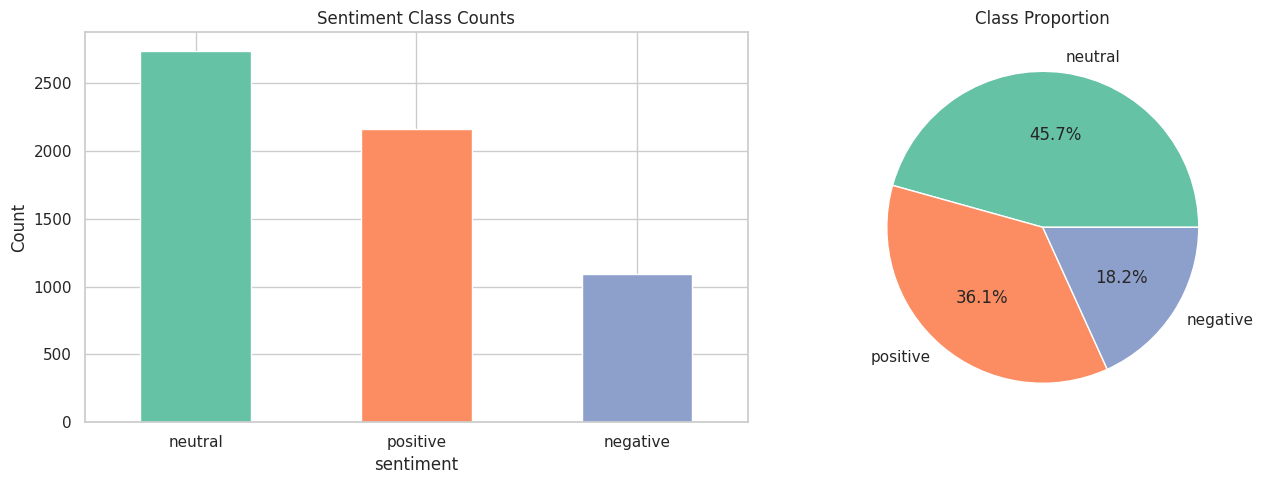

In [ ]:
# 3.1 Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Sentiment Class Counts'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[1].pie(df['sentiment'].value_counts(), labels=df['sentiment'].value_counts().index,
            autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Class Proportion')
plt.tight_layout(); plt.show()

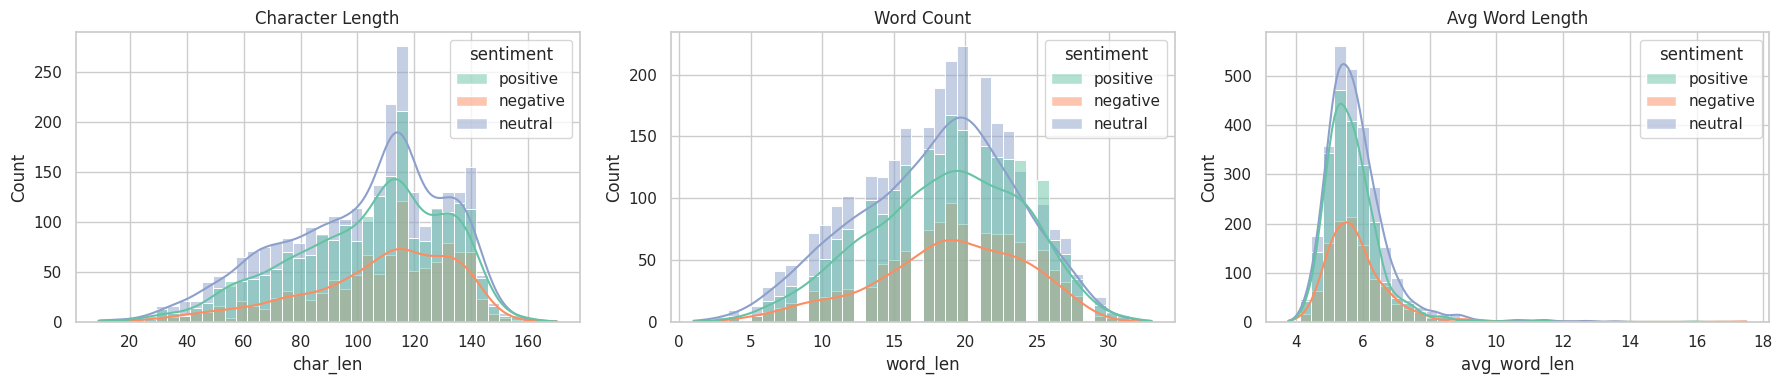

In [ ]:
# 3.2 Length features
df['char_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.split().apply(len)
df['avg_word_len'] = df['char_len'] / df['word_len'].replace(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, title in zip(axes, ['char_len','word_len','avg_word_len'],
                          ['Character Length','Word Count','Avg Word Length']):
    sns.histplot(data=df, x=col, hue='sentiment', kde=True, bins=40, ax=ax)
    ax.set_title(title)
plt.tight_layout(); plt.show()

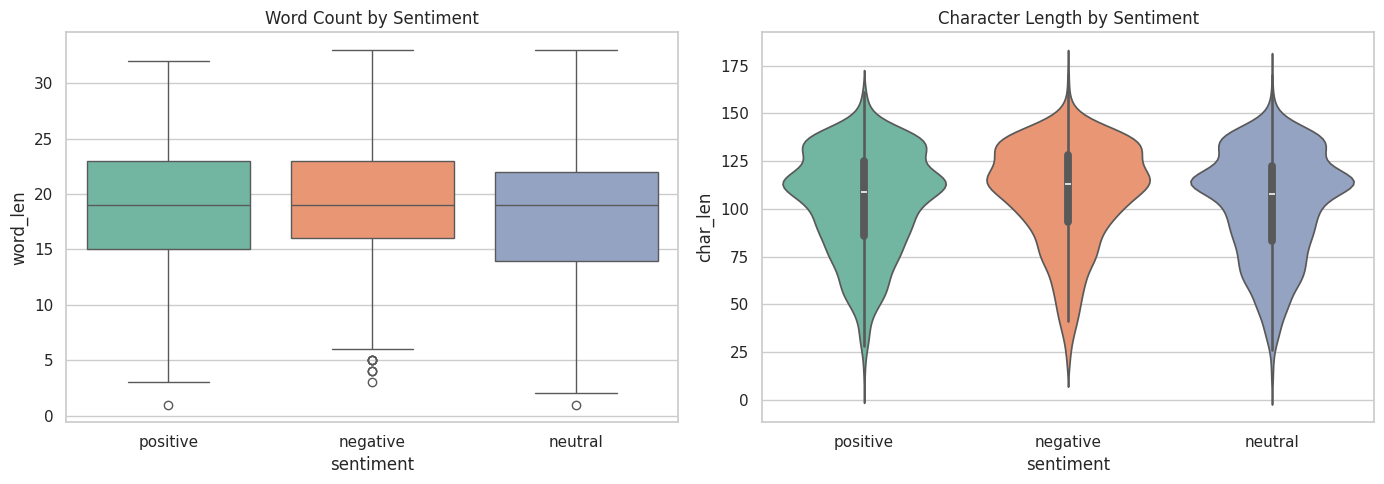

In [ ]:
# 3.3 Multivariate — boxplots and violin plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='sentiment', y='word_len', ax=axes[0], palette='Set2')
axes[0].set_title('Word Count by Sentiment')
sns.violinplot(data=df, x='sentiment', y='char_len', ax=axes[1], palette='Set2')
axes[1].set_title('Character Length by Sentiment')
plt.tight_layout(); plt.show()

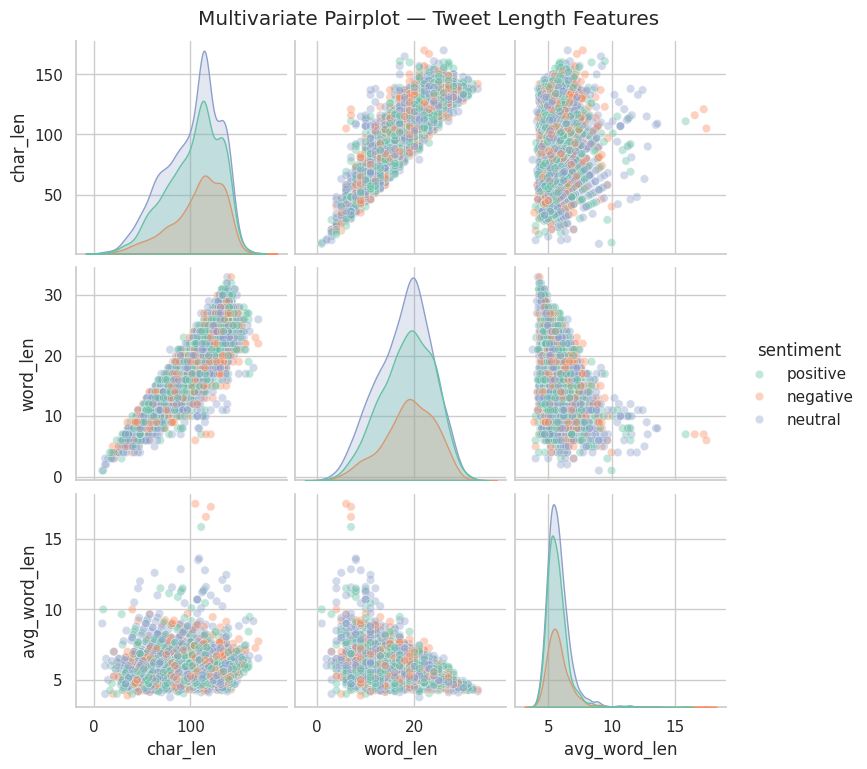

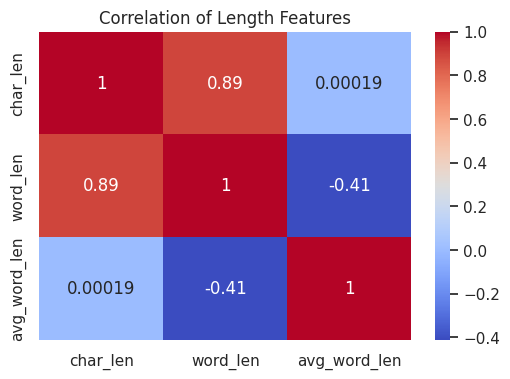

In [ ]:
# 3.4 Pairplot of numeric features
sns.pairplot(df[['char_len','word_len','avg_word_len','sentiment']], hue='sentiment',
             diag_kind='kde', palette='Set2', plot_kws={'alpha':0.4})
plt.suptitle('Multivariate Pairplot — Tweet Length Features', y=1.02)
plt.show()

# Correlation matrix
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(df[['char_len','word_len','avg_word_len']].corr(), annot=True, cmap='coolwarm', ax=ax)
ax.set_title('Correlation of Length Features')
plt.show()

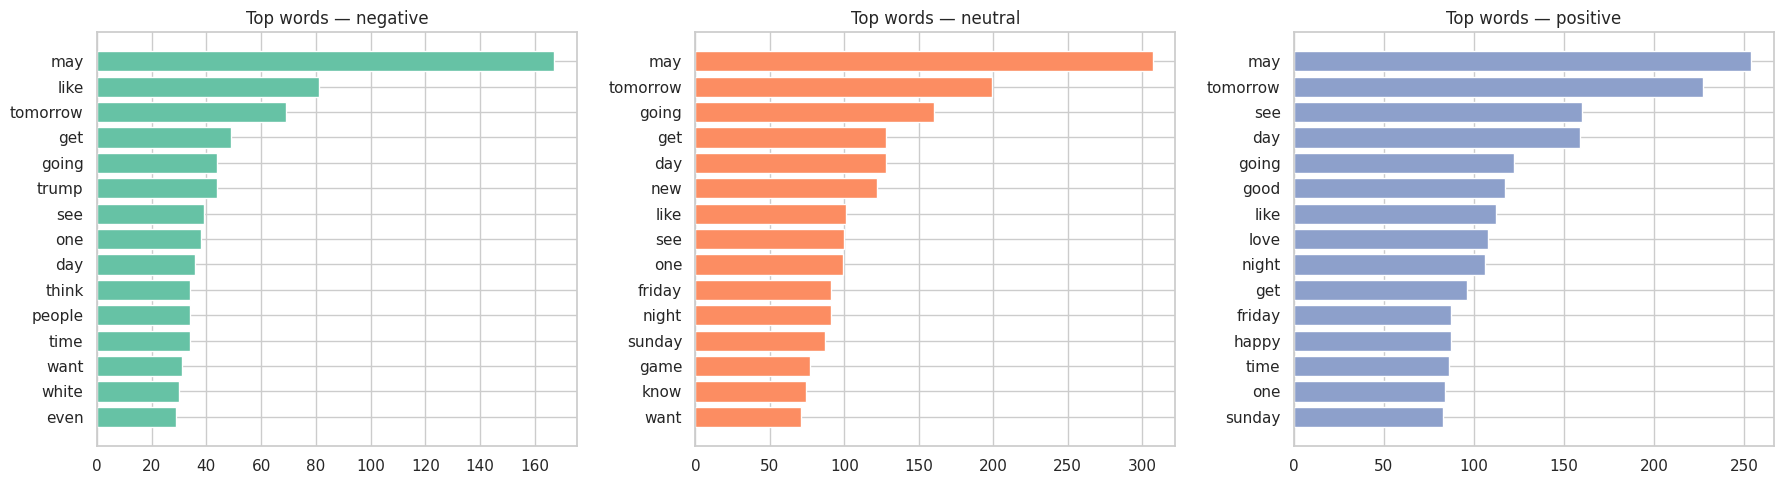

In [ ]:
# 3.5 Top words per class (raw, before cleaning)
stop = set(stopwords.words('english'))

def top_words(text_series, n=15):
    words = ' '.join(text_series).lower().split()
    words = [w.strip(string.punctuation) for w in words
             if w.isalpha() and w not in stop and len(w) > 2]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, sent in zip(axes, ['negative','neutral','positive']):
    tw = top_words(df[df['sentiment']==sent]['text'])
    words, counts = zip(*tw)
    ax.barh(words[::-1], counts[::-1], color=sns.color_palette('Set2')[axes.tolist().index(ax)])
    ax.set_title(f'Top words — {sent}')
plt.tight_layout(); plt.show()

## 4. Word Clouds

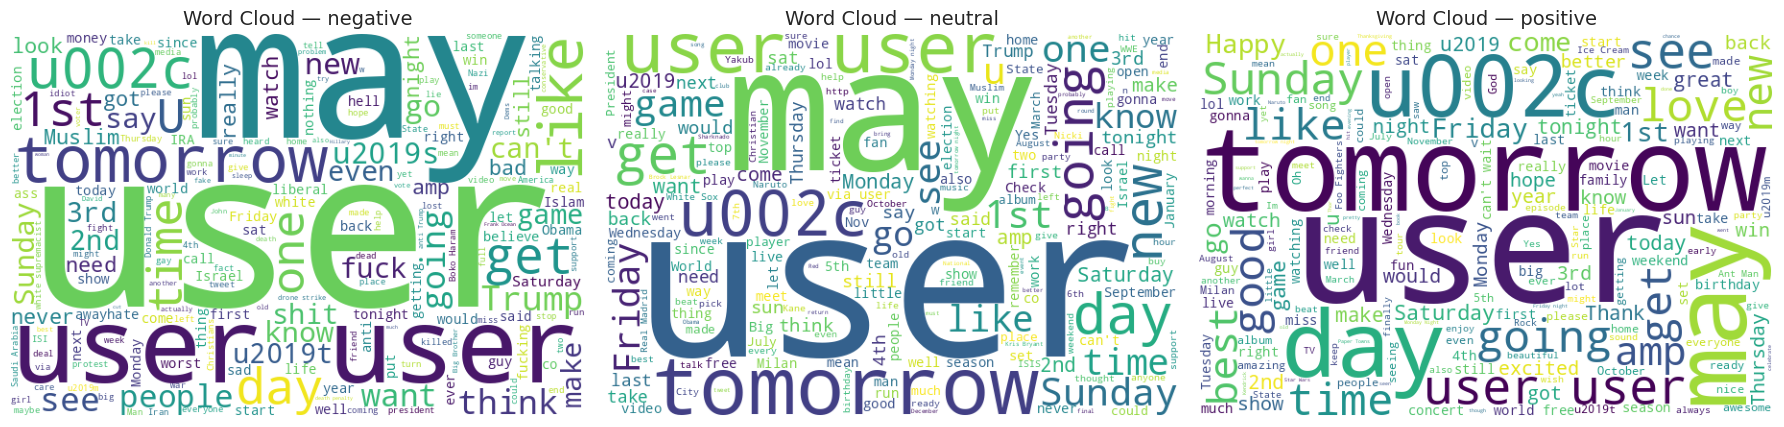

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, sent in zip(axes, ['negative','neutral','positive']):
    text = ' '.join(df[df['sentiment']==sent]['text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   stopwords=stop, colormap='viridis').generate(text)
    ax.imshow(wc); ax.axis('off'); ax.set_title(f'Word Cloud — {sent}', fontsize=14)
plt.tight_layout(); plt.show()

## 5. Text Cleaning

In [ ]:
lemma = WordNetLemmatizer()
URL_RE     = re.compile(r'http\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
HASH_RE    = re.compile(r'#')
EMOJI_RE   = re.compile('['
    u'\U0001F600-\U0001F64F'
    u'\U0001F300-\U0001F5FF'
    u'\U0001F680-\U0001F6FF'
    u'\U0001F1E0-\U0001F1FF'
    u'\U00002700-\U000027BF'
    u'\U000024C2-\U0001F251'
    ']+', flags=re.UNICODE)

def clean(text):
    text = text.lower()
    text = URL_RE.sub(' ', text)
    text = MENTION_RE.sub(' ', text)
    text = HASH_RE.sub(' ', text)
    text = EMOJI_RE.sub(' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemma.lemmatize(t) for t in text.split() if t not in stop and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
df[['text','clean_text','sentiment']].head()

,text,clean_text,sentiment
0,@user @user BJP may be liking Rahul Gandhi now...,bjp may liking rahul gandhi rahul speaks bjp gain,positive
1,The guy who let me borrow his Ohio State bag F...,guy let borrow ohio state bag friday night sai...,positive
2,@user @user will NEVER but the sun Jo\u002c ne...,never sun never even guaranteed date dave groh...,negative
3,Friday post-game IHOP is having their 2nd annu...,friday post game ihop annual pancake bonanza f...,neutral
4,@user For when your working day eventually end...,working day eventually end david bowie speed l...,positive


In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['sentiment'], test_size=0.2, stratify=df['sentiment'], random_state=SEED)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (4800,) Test: (1200,)


## 6. TF-IDF Feature Extraction

In [ ]:
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=2)
Xtr_tfidf = tfidf.fit_transform(X_train)
Xte_tfidf = tfidf.transform(X_test)
print('TF-IDF matrix:', Xtr_tfidf.shape)

TF-IDF matrix: (4800, 6832)


## 7-9. Classical Models

In [ ]:
models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'Multinomial NB':      MultinomialNB(),
    'Linear SVM':          LinearSVC(C=1.0)
}

results = {}
for name, mdl in models_clf.items():
    mdl.fit(Xtr_tfidf, y_train)
    preds = mdl.predict(Xte_tfidf)
    results[name] = {
        'preds': preds,
        'acc':   accuracy_score(y_test, preds),
        'f1':    f1_score(y_test, preds, average='weighted'),
    }
    print(f"{name}: acc={results[name]['acc']:.4f} | f1={results[name]['f1']:.4f}")

Logistic Regression: acc=0.6017 | f1=0.5846
Multinomial NB: acc=0.5958 | f1=0.5615
Linear SVM: acc=0.5675 | f1=0.5618


## 10. Small LSTM Model

In [ ]:
VOCAB = 10000
MAX_LEN = 40
EMB_DIM = 64

tokenizer = Tokenizer(num_words=VOCAB, oov_token='<UNK>')
tokenizer.fit_on_texts(X_train)
Xtr_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
Xte_seq = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post')

label_to_idx = {l:i for i,l in enumerate(sorted(df['sentiment'].unique()))}
idx_to_label = {i:l for l,i in label_to_idx.items()}
ytr_idx = y_train.map(label_to_idx).values
yte_idx = y_test.map(label_to_idx).values

lstm = models.Sequential([
    layers.Embedding(VOCAB, EMB_DIM, input_length=MAX_LEN),
    layers.Bidirectional(layers.LSTM(64, dropout=0.3, recurrent_dropout=0.0)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(3, activation='softmax')
])
lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm.summary()

es = tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
hist = lstm.fit(Xtr_seq, ytr_idx, validation_split=0.1, epochs=8, batch_size=64,
                callbacks=[es], verbose=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.4356 - loss: 1.0478 - val_accuracy: 0.4667 - val_loss: 1.0170
Epoch 2/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5178 - loss: 0.9591 - val_accuracy: 0.5854 - val_loss: 0.8862
Epoch 3/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7535 - loss: 0.6189 - val_accuracy: 0.5250 - val_loss: 1.0127
Epoch 4/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8762 - loss: 0.3527 - val_accuracy: 0.5562 - val_loss: 1.4031


In [ ]:
lstm_probs = lstm.predict(Xte_seq, verbose=0)
lstm_pred_idx = lstm_probs.argmax(axis=1)
lstm_preds = [idx_to_label[i] for i in lstm_pred_idx]
results['LSTM'] = {
    'preds': np.array(lstm_preds),
    'acc':   accuracy_score(y_test, lstm_preds),
    'f1':    f1_score(y_test, lstm_preds, average='weighted'),
}
print(f"LSTM: acc={results['LSTM']['acc']:.4f} | f1={results['LSTM']['f1']:.4f}")

LSTM: acc=0.5517 | f1=0.5353


## 11. Comparative Evaluation

                     Accuracy  Weighted F1
Logistic Regression  0.601667     0.584620
Multinomial NB       0.595833     0.561490
Linear SVM           0.567500     0.561774
LSTM                 0.551667     0.535307


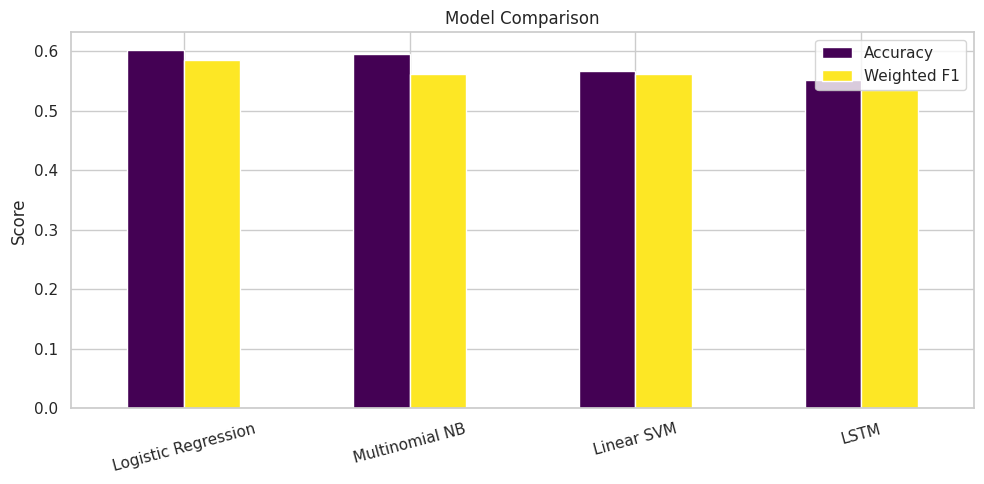

In [ ]:
summary = pd.DataFrame({k: {'Accuracy': v['acc'], 'Weighted F1': v['f1']}
                        for k, v in results.items()}).T.sort_values('Accuracy', ascending=False)
print(summary)

summary.plot(kind='bar', figsize=(10,5), colormap='viridis')
plt.title('Model Comparison'); plt.ylabel('Score'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

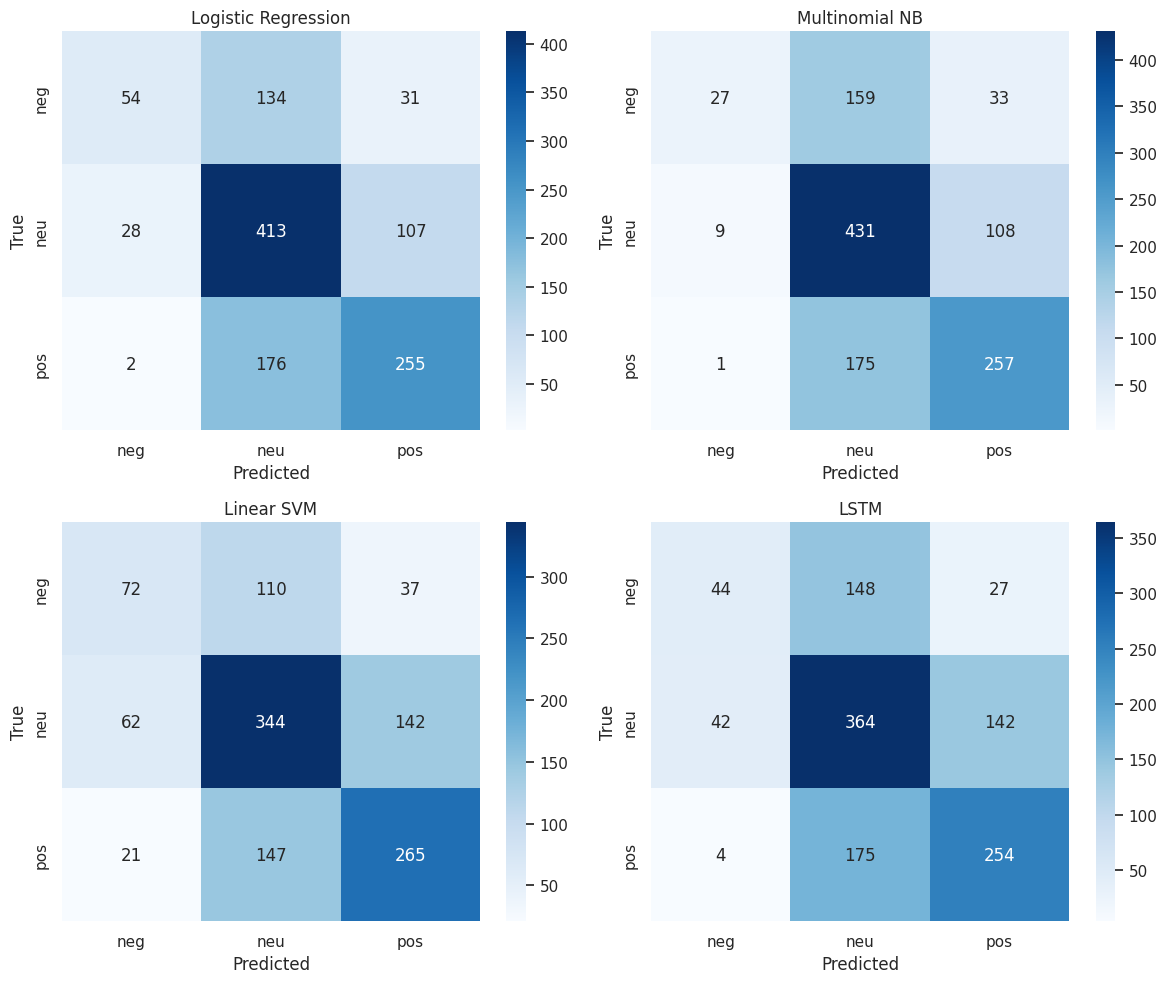


=== Best model: Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.64      0.25      0.36       219
     neutral       0.57      0.75      0.65       548
    positive       0.65      0.59      0.62       433

    accuracy                           0.60      1200
   macro avg       0.62      0.53      0.54      1200
weighted avg       0.61      0.60      0.58      1200



In [ ]:
# Confusion matrices side-by-side
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, res) in zip(axes.flat, results.items()):
    cm = confusion_matrix(y_test, res['preds'], labels=['negative','neutral','positive'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['neg','neu','pos'], yticklabels=['neg','neu','pos'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

# Detailed report for the best classical model
best = max(results, key=lambda k: results[k]['acc'])
print(f"\n=== Best model: {best} ===")
print(classification_report(y_test, results[best]['preds']))

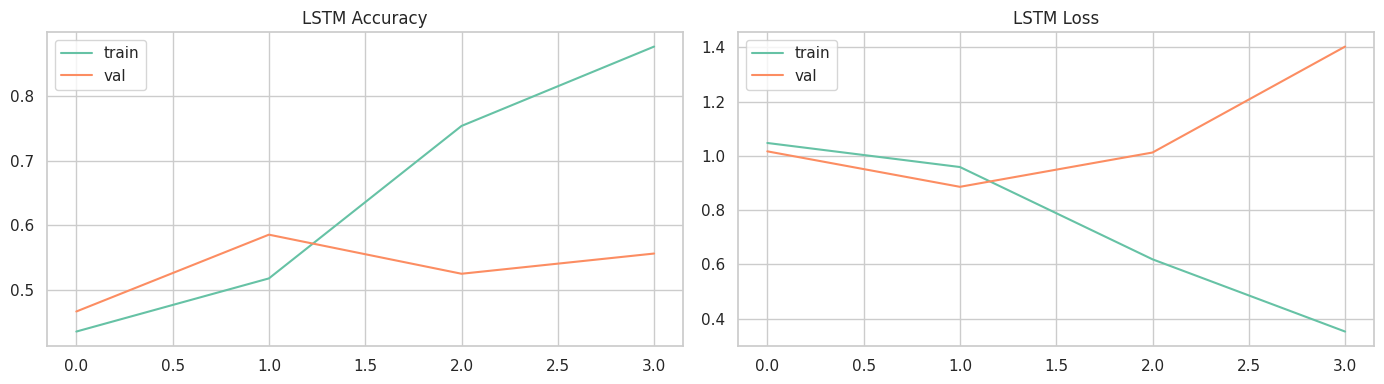

In [ ]:
# LSTM training curves
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(hist.history['accuracy'], label='train')
ax[0].plot(hist.history['val_accuracy'], label='val')
ax[0].set_title('LSTM Accuracy'); ax[0].legend()
ax[1].plot(hist.history['loss'], label='train')
ax[1].plot(hist.history['val_loss'], label='val')
ax[1].set_title('LSTM Loss'); ax[1].legend()
plt.tight_layout(); plt.show()